<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/Cat_vs_non_cat_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cat or non cat classifier using Convolutional Neural Network (CNN)**


![catvsnon](https://datahacker.rs/wp-content/uploads/2018/06/word-image-58.png)

## **Context**



**What is a Convolutional Neural Network (CNN)?**

A Convolutional Neural Network (CNN) is a specialized type of neural network designed to process data with a known grid-like topology, such as image data. Its architecture is particularly well-suited for tasks like image classification, object detection, and segmentation. Key features of CNNs include:
1.  **Convolutional Layers**: These layers apply various filters (kernels) to the input data to create feature maps, detecting patterns like edges, textures, or shapes.
2.  **Pooling Layers**: These layers reduce the spatial dimensions of the feature maps, helping to decrease computational complexity and control overfitting. Common pooling operations include max pooling and average pooling.
3.  **Activation Functions**: Non-linear functions (like ReLU) are applied after convolutional layers to introduce non-linearity, allowing the network to learn more complex patterns.
4.  **Fully Connected Layers**: After several convolutional and pooling layers, the data is typically flattened and fed into one or more fully connected layers, which perform high-level reasoning based on the extracted features.

This hierarchical structure allows CNNs to automatically learn spatial hierarchies of features, from low-level edges to high-level object parts, making them highly effective for computer vision tasks.

**Case: The Cat/Non-Cat Classification Case using CNN**

Previously, we have built neural network model of cat vs non-cat classifier using deep neural network in this [notebook](https://github.com/harishmuh/Computer_Vision_study/blob/main/Cat_vs_non_cat_DNN.ipynb). In this current tutorial, we will also build neural neural network for image classifier, but using a Convolutional Neural Network (CNN) to distinguish between images that contain a cat and those that do not (non-cat). The dataset consists of a collection of images, each labeled as either 'cat' (1) or 'non-cat' (0). The goal is to train a model that can accurately predict the label of a new, unseen image. This involves:
1.  **Loading and preprocessing** the image data, maintaining its spatial structure.
2.  **Building and training** a Convolutional Neural Network model.
3.  **Evaluating** the model's performance on a test set.
4.  **Making predictions** on new images.

The images are represented as numerical pixel values, and the challenge lies in teaching the CNN to recognize the characteristic visual patterns of cat images versus non-cat images by extracting and learning relevant features through its convolutional layers.

We will start by importing the required libraries for the experiment.

**Initial setup**

In [7]:
# Import required libraries
import numpy as np
import copy
import matplotlib.pyplot as plt
import h5py
import scipy

import tensorflow as tf # Deeplearning frame work
from tensorflow import keras # Model building

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

import warnings
warnings.filterwarnings('ignore')


## **Loading and process dataset**



We will use a dataset ("data.h5") containing:
* a training set of m_train images labelled as cat (1) or non-cat (0)
* a test set of m_test images labelled as cat and non-cat
* each image is of shape (num_px, num_px, 3) where 3 is for the 3 channels (RGB).

In [8]:
# Downloading dataset
!wget https://raw.githubusercontent.com/harishmuh/Deep-Learning-Specialization---Andrew-Ng/main/1.%20Neural%20Networks%20and%20Deep%20Learning/week4/W4A2/datasets/train_catvnoncat.h5
!wget https://raw.githubusercontent.com/harishmuh/Deep-Learning-Specialization---Andrew-Ng/main/1.%20Neural%20Networks%20and%20Deep%20Learning/week4/W4A2/datasets/test_catvnoncat.h5

--2026-04-30 05:59:21--  https://raw.githubusercontent.com/harishmuh/Deep-Learning-Specialization---Andrew-Ng/main/1.%20Neural%20Networks%20and%20Deep%20Learning/week4/W4A2/datasets/train_catvnoncat.h5
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2572022 (2.5M) [application/octet-stream]
Saving to: ‘train_catvnoncat.h5’

train_catvnoncat.h5 100%[===================>]   2.45M  --.-KB/s    in 0.04s   

2026-04-30 05:59:22 (59.2 MB/s) - ‘train_catvnoncat.h5’ saved [2572022/2572022]

--2026-04-30 05:59:22--  https://raw.githubusercontent.com/harishmuh/Deep-Learning-Specialization---Andrew-Ng/main/1.%20Neural%20Networks%20and%20Deep%20Learning/week4/W4A2/datasets/test_catvnoncat.h5
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.

In [9]:
# Loading the data (cat/non-cat)

# Function to load dataset
def load_dataset():
    train_dataset = h5py.File('train_catvnoncat.h5', "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # train set labels

    test_dataset = h5py.File('test_catvnoncat.h5', "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes

    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

In [10]:
# Loading the data (cat/non-cat)
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

y = [1], it's a 'cat' picture.


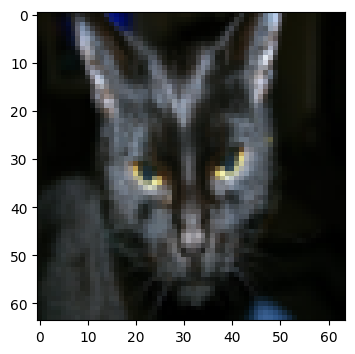

In [11]:
# Example of a picture
index = 25
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")

y = 0. It's a non-cat picture.


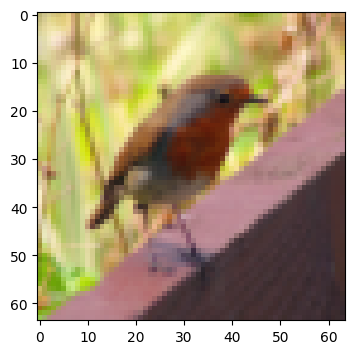

In [12]:
# Example of a picture
index = 10
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[0,index]) + ". It's a " + classes[train_set_y[0,index]].decode("utf-8") +  " picture.")

In [13]:
# Explore the dataset
m_train = train_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]
m_test = test_set_x_orig.shape[0]

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_set_x_orig.shape))
print ("train_y shape: " + str(train_set_y.shape))
print ("test_x_orig shape: " + str(test_set_x_orig.shape))
print ("test_y shape: " + str(test_set_y.shape))

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)


We will do standarization

![image](https://raw.githubusercontent.com/harishmuh/Deep-Learning-Specialization---Andrew-Ng/e3b4b727f95a1f3d4fc4c42038c49f5cc33b6811/1.%20Neural%20Networks%20and%20Deep%20Learning/week4/W4A2/images/imvectorkiank.png)
Figure 1. Image to vectors conversion

In [14]:
import tensorflow as tf

# Standardize data to have feature values between 0 and 1.
train_x = train_set_x_orig / 255.0
test_x = test_set_x_orig / 255.0

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (209, 64, 64, 3)
test_x's shape: (50, 64, 64, 3)


## **Model building**

In [15]:
# Model building with CNN

tf.random.set_seed(1)

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(num_px, num_px, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [16]:
# Compiling model
model.compile(
    loss = keras.losses.BinaryCrossentropy(from_logits = False),
    optimizer = keras.optimizers.SGD(learning_rate = 0.0075),
    metrics = ["accuracy"]
)

## **Model training**

In [17]:
history = model.fit(train_x, train_set_y.T, batch_size = 209, epochs = 500, verbose = 2) #batch_size = 209 = number of train examples, to have batch gradient descent

Epoch 1/500
1/1 - 2s - 2s/step - accuracy: 0.6555 - loss: 0.6677
Epoch 2/500
1/1 - 3s - 3s/step - accuracy: 0.6555 - loss: 0.6592
Epoch 3/500
1/1 - 2s - 2s/step - accuracy: 0.6555 - loss: 0.6530
Epoch 4/500
1/1 - 1s - 1s/step - accuracy: 0.6555 - loss: 0.6487
Epoch 5/500
1/1 - 1s - 1s/step - accuracy: 0.6555 - loss: 0.6457
Epoch 6/500
1/1 - 1s - 1s/step - accuracy: 0.6555 - loss: 0.6436
Epoch 7/500
1/1 - 1s - 1s/step - accuracy: 0.6555 - loss: 0.6420
Epoch 8/500
1/1 - 1s - 1s/step - accuracy: 0.6555 - loss: 0.6409
Epoch 9/500
1/1 - 1s - 1s/step - accuracy: 0.6555 - loss: 0.6399
Epoch 10/500
1/1 - 1s - 1s/step - accuracy: 0.6555 - loss: 0.6392
Epoch 11/500
1/1 - 2s - 2s/step - accuracy: 0.6555 - loss: 0.6386
Epoch 12/500
1/1 - 2s - 2s/step - accuracy: 0.6555 - loss: 0.6380
Epoch 13/500
1/1 - 1s - 1s/step - accuracy: 0.6555 - loss: 0.6375
Epoch 14/500
1/1 - 1s - 1s/step - accuracy: 0.6555 - loss: 0.6371
Epoch 15/500
1/1 - 1s - 1s/step - accuracy: 0.6555 - loss: 0.6366
Epoch 16/500
1/1 - 

## **Model evaluation**

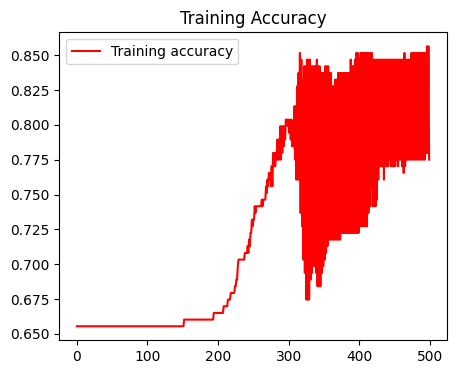

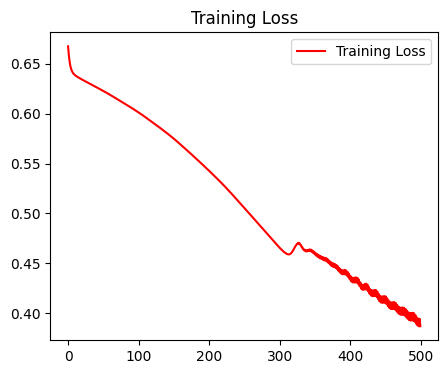

In [18]:
# Plot Accuracy and Loss
import matplotlib.pyplot as plt
acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(len(acc))

# Plot Training Accuracy
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.title('Training Accuracy')
plt.legend(loc=0)
plt.figure() # Create a new figure for the loss plot

# Plot Training Loss
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.title('Training Loss')
plt.legend(loc=0)

plt.show()

In [19]:
# Model evaluation
test_loss, test_acc = model.evaluate(test_x, test_set_y.T, verbose=2)
print(f'Accuracy: {test_acc:.4f}')

2/2 - 0s - 138ms/step - accuracy: 0.8400 - loss: 0.4292
Accuracy: 0.8400


We get accuracy score of 0.84 on the testing dataset. This score is higher than the [previous DNN model](https://github.com/harishmuh/Computer_Vision_study/blob/main/Cat_vs_non_cat_DNN.ipynb) with accuracy of 0.78.


Actually this score can be further improved by various measures like adding more layers to increase complexity, conducting data augmentation, implementing regularization and earlystopping, etc.

## **Prediction simulation**

Let's simulate by uploading photos of cat and non-cat (or may be your own photo).

Saving kucing_itb_1.JPG to kucing_itb_1 (1).JPG


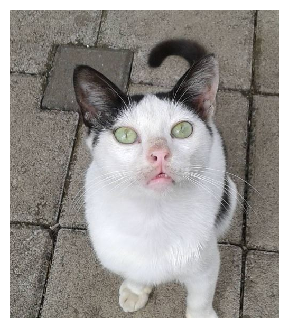

Model prediction: cat (Probability: 0.7422)


In [22]:
# Upload, display uploaded image, and predict
import io
from PIL import Image
from google.colab import files
from keras.preprocessing import image
import numpy as np # Import numpy

uploaded = files.upload()  # Upload image manually

for fn in uploaded.keys():

  # ---------- DISPLAY IMAGE ----------
  image_bytes = uploaded[fn]  # Get image bytes

  img_display = Image.open(io.BytesIO(image_bytes)).convert("RGB")
  plt.imshow(img_display)
  plt.axis('off')
  plt.show()

  # ---------- PREPROCESS FOR MODEL ----------
  path = fn
  # Resize image to the expected num_px (64, 64) as used during training
  img = image.load_img(path, target_size=(num_px, num_px))
  x = image.img_to_array(img)  # Convert to numpy array (shape: num_px, num_px, 3)
  x = x / 255.0  # Normalize
  # Add a batch dimension to match CNN model input (1, num_px, num_px, 3)
  x = np.expand_dims(x, axis=0)

  # ---------- PREDICT ----------
  # Pass the preprocessed image 'x' directly to the model
  predictions = model.predict(x, verbose=0)
  prediction_probability = predictions[0][0]

  # ---------- CONVERT TO LABEL ----------
  # 'classes' variable is available from load_dataset(), which is [b'non-cat', b'cat']
  # Map the probability to a label (0 for non-cat, 1 for cat)
  if prediction_probability > 0.5:
    predicted_label = classes[1].decode("utf-8") # Index 1 is 'cat'
  else:
    predicted_label = classes[0].decode("utf-8") # Index 0 is 'non-cat'

  print(f"Model prediction: {predicted_label} (Probability: {prediction_probability:.4f})")

The model has predicted the uploaded image correctly.

Saving magdeburg.JPG to magdeburg.JPG


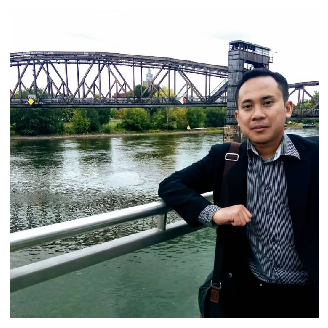

Model prediction: non-cat (Probability: 0.1611)


In [24]:
# Upload, display uploaded image, and predict
import io
from PIL import Image
from google.colab import files
from keras.preprocessing import image
import numpy as np # Import numpy

uploaded = files.upload()  # Upload image manually

for fn in uploaded.keys():

  # ---------- DISPLAY IMAGE ----------
  image_bytes = uploaded[fn]  # Get image bytes

  img_display = Image.open(io.BytesIO(image_bytes)).convert("RGB")
  plt.imshow(img_display)
  plt.axis('off')
  plt.show()

  # ---------- PREPROCESS FOR MODEL ----------
  path = fn
  # Resize image to the expected num_px (64, 64) as used during training
  img = image.load_img(path, target_size=(num_px, num_px))
  x = image.img_to_array(img)  # Convert to numpy array (shape: num_px, num_px, 3)
  x = x / 255.0  # Normalize
  # Add a batch dimension to match CNN model input (1, num_px, num_px, 3)
  x = np.expand_dims(x, axis=0)

  # ---------- PREDICT ----------
  # Pass the preprocessed image 'x' directly to the model
  predictions = model.predict(x, verbose=0)
  prediction_probability = predictions[0][0]

  # ---------- CONVERT TO LABEL ----------
  # 'classes' variable is available from load_dataset(), which is [b'non-cat', b'cat']
  # Map the probability to a label (0 for non-cat, 1 for cat)
  if prediction_probability > 0.5:
    predicted_label = classes[1].decode("utf-8") # Index 1 is 'cat'
  else:
    predicted_label = classes[0].decode("utf-8") # Index 0 is 'non-cat'

  print(f"Model prediction: {predicted_label} (Probability: {prediction_probability:.4f})")

## **Conclusion**

In this notebook, we successfully built and trained a Convolutional Neural Network (CNN) to classify images as either 'cat' or 'non-cat'. We have covered topics such as:

1.  **Data Loading and Preprocessing:** We loaded the dataset, explored its structure, and preprocessed the images by reshaping and standardizing their pixel values, maintaining their spatial dimensions for CNN input.
2.  **Model Building:** We constructed a sequential Convolutional Neural Network (CNN) using TensorFlow/Keras with convolutional, pooling, flatten, and dense layers, along with appropriate activation functions.
3.  **Model Training:** The model was compiled with binary cross-entropy loss and an SGD optimizer, and then trained for 500 epochs.
4.  **Model Evaluation:** We visualized the training accuracy and loss, and evaluated the model's performance on a held-out test set, achieving an accuracy of 84%.
5.  **Prediction Simulation:** We demonstrated how to use the trained model to predict whether a new, uploaded image contains a cat or not.

While the model achieved a reasonable accuracy, we identified several potential areas for further improvement, such as conducting data augmentation, using more advanced CNN architectures, experimenting with different hyperparameters, or implementing regularization and early stopping to further enhance performance and generalization.

